In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('dataset/bank_transactions_data_2.csv') # Adjusted path based on upload
print(df.shape)
print(df.info())
print(df.head())

(2512, 16)
<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   str    
 1   AccountID                2512 non-null   str    
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   str    
 4   TransactionType          2512 non-null   str    
 5   Location                 2512 non-null   str    
 6   DeviceID                 2512 non-null   str    
 7   IP Address               2512 non-null   str    
 8   MerchantID               2512 non-null   str    
 9   Channel                  2512 non-null   str    
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   str    
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [3]:
# Check for null values in the feature set
features = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
print(df[features].isnull().sum())

TransactionAmount      0
CustomerAge            0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
dtype: int64


In [4]:
# Select features for modeling
X = df[features].values

# Use RobustScaler to handle outliers better during the scaling process
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
print("Data scaled using RobustScaler.")

Data scaled using RobustScaler.


In [5]:
# Initialize Isolation Forest
# contamination=0.01 assumes roughly 1% of transactions are outliers
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# Fit and predict
# 1 = Normal, -1 = Outlier
df['Is_Outlier'] = iso_forest.fit_predict(X_scaled)

outliers_count = (df['Is_Outlier'] == -1).sum()
print(f"Number of outliers detected by Isolation Forest: {outliers_count}")

Number of outliers detected by Isolation Forest: 26


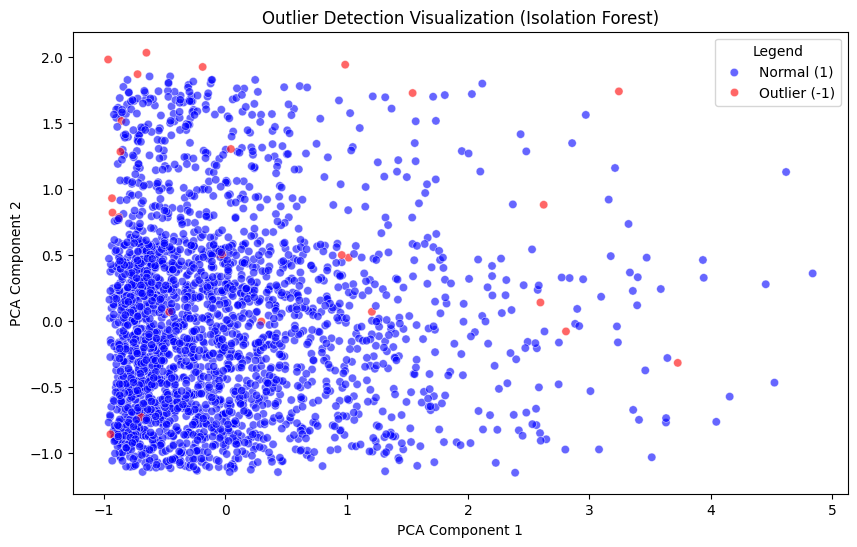

In [6]:
# Reduce dimensions for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Is_Outlier'], palette={1: 'blue', -1: 'red'}, alpha=0.6)
plt.title('Outlier Detection Visualization (Isolation Forest)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Legend', labels=['Normal (1)', 'Outlier (-1)'])
plt.show()

In [7]:
import pickle
import os

if not os.path.exists('models'):
    os.makedirs('models')

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('models/iso_forest_model.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)

print("Improved models saved successfully.")

Improved models saved successfully.


In [8]:
# Run DBSCAN with the tuned eps (1.5 is a better starting point for RobustScaler)
dbscan = DBSCAN(eps=1.5, min_samples=10)
labels_db = dbscan.fit_predict(X_scaled)
outliers_dbscan = (labels_db == -1)

print(f"DBSCAN: {outliers_dbscan.sum()} outliers detected.")

DBSCAN: 5 outliers detected.


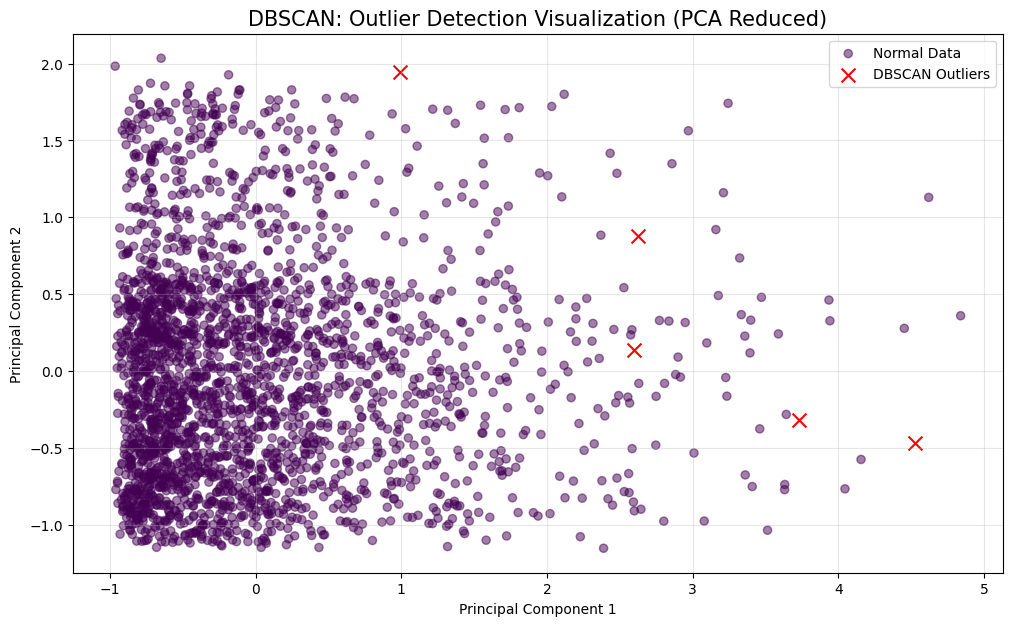

In [11]:
plt.figure(figsize=(12, 7))

# Plot clusters
plt.scatter(X_pca[labels_db != -1, 0], X_pca[labels_db != -1, 1], 
            c=labels_db[labels_db != -1], cmap='viridis', s=35, alpha=0.5, label='Normal Data')

# Plot Outliers (Red X's)
plt.scatter(X_pca[labels_db == -1, 0], X_pca[labels_db == -1, 1], 
            c='red', marker='x', s=100, label='DBSCAN Outliers')

plt.title('DBSCAN: Outlier Detection Visualization (PCA Reduced)', fontsize=15)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 1. Identify which indices are 'core' samples
core_samples_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

# 2. Extract the actual feature values and labels for these core points
core_points = X_scaled[core_samples_mask]
core_labels = dbscan.labels_[core_samples_mask]

# 3. Define the eps value (ensure this matches what you used in DBSCAN)
eps = 1.5 

print(f"Core points defined. Found {len(core_points)} core samples.")

Core points defined. Found 2492 core samples.


In [ ]:
import pickle
import os


if not os.path.exists('models'):
    os.makedirs('models')


with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('models/iso_forest.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)

with open('models/dbscan_core_points.pkl', 'wb') as f:
    pickle.dump(core_points, f)

with open('models/eps.pkl', 'wb') as f:
    pickle.dump(eps, f)

print("files saved: scaler,dbscan_core_points, and eps.")

All 4 files saved: scaler, iso_forest, dbscan_core_points, and eps.


In [ ]:
import pickle
import os


if not os.path.exists('models'):
    os.makedirs('models')


with open('models/iso_forest.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)

print("Success! 'models/iso_forest.pkl' has been created.")

Success! 'models/iso_forest.pkl' has been created.


New vertical stack plot saved to static/cluster.png


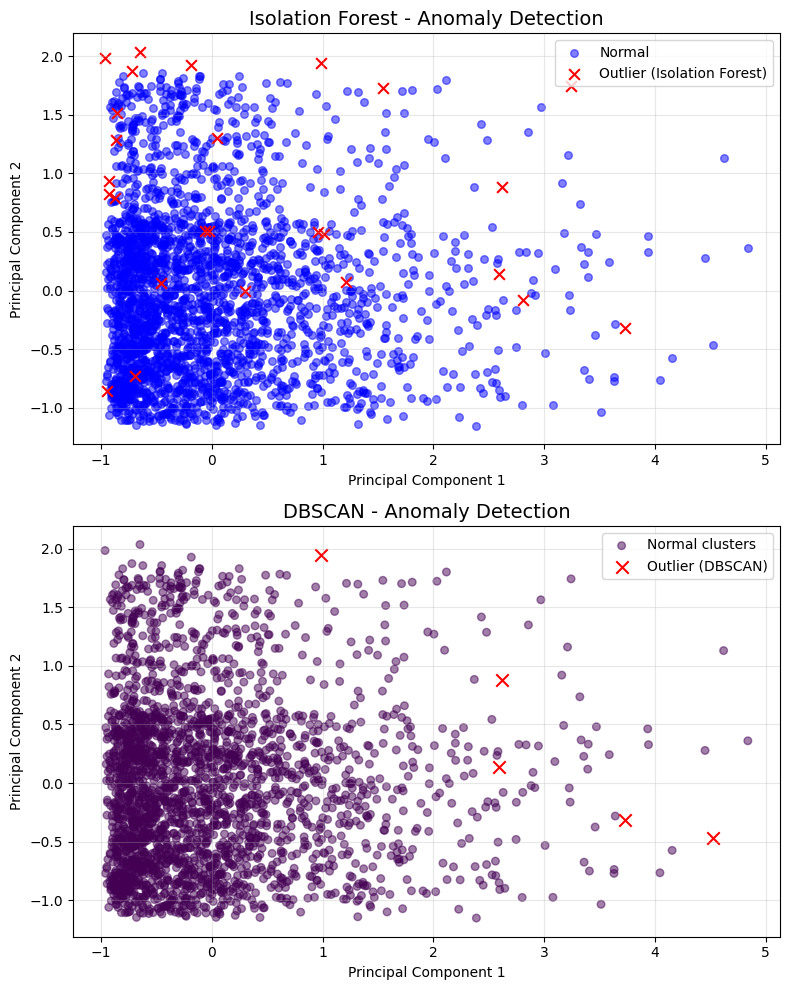

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

outliers_iso = df['Is_Outlier'] == -1
normals_iso = df['Is_Outlier'] == 1

ax1.scatter(X_pca[normals_iso, 0], X_pca[normals_iso, 1],
            c='blue', s=30, alpha=0.5, label='Normal')
ax1.scatter(X_pca[outliers_iso, 0], X_pca[outliers_iso, 1],
            c='red', s=60, marker='x', label='Outlier (Isolation Forest)')
ax1.set_title('Isolation Forest - Anomaly Detection', fontsize=14)
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.legend()
ax1.grid(True, alpha=0.3)


outliers_db = labels_db == -1
normals_db = labels_db != -1

ax2.scatter(X_pca[normals_db, 0], X_pca[normals_db, 1],
            c=labels_db[normals_db], cmap='viridis', s=30, alpha=0.5, label='Normal clusters')
ax2.scatter(X_pca[outliers_db, 0], X_pca[outliers_db, 1],
            c='red', s=80, marker='x', label='Outlier (DBSCAN)')
ax2.set_title('DBSCAN - Anomaly Detection', fontsize=14)
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('static/cluster.png', dpi=150, bbox_inches='tight')
print("New vertical stack plot saved to static/cluster.png")